# Baseline - boxplot for Top-1, Top-5 and MRR results

## Python imports

In [10]:
import Common
import matplotlib.ticker 
import matplotlib.pyplot as pyplt
import pandas as pd

## Read FTLS results

In [11]:
data = pd.read_csv('../floralens/flts_floralens.tsv', sep='\t')
data 

,filename,species,rank1,c1,rank2,c2,rank3,c3,rank4,c4,rank5,c5
0,Acacia_dealbata_1945424512_1.jpg,Acacia dealbata,Acacia dealbata,0.796078,Acacia longifolia,0.105882,Hakea salicifolia,0.011765,Acacia melanoxylon,0.011765,Medicago arborea,0.003922
1,Acacia_dealbata_2974327900_1.jpg,Acacia dealbata,Acacia mearnsii,0.227451,Pteridium aquilinum,0.203922,Acacia dealbata,0.141176,Paraserianthes lophantha,0.015686,Dryopteris affinis,0.007843
2,Acacia_dealbata_1946199420_3.jpg,Acacia dealbata,Salix fragilis,0.117647,Quercus suber,0.082353,Schoenoplectus lacustris,0.027451,Cryptomeria japonica,0.027451,Acacia dealbata,0.023529
3,Acacia_dealbata_1945436102_1.jpg,Acacia dealbata,Buddleja davidii,0.247059,Ipomoea indica,0.058824,Ficus carica,0.054902,Solanum villosum,0.054902,Datura stramonium,0.035294
4,Acacia_dealbata_1805367892_1.jpg,Acacia dealbata,Acacia dealbata,0.615686,Bupleurum fruticosum,0.058824,Acacia saligna,0.047059,Pittosporum undulatum,0.019608,Acacia melanoxylon,0.015686
...,...,...,...,...,...,...,...,...,...,...,...,...
29355,Zostera_noltii_2242774794_1.jpg,Zostera noltii,Cymodocea nodosa,0.388235,Hordeum secalinum,0.105882,Zannichellia palustris,0.043137,Genista florida,0.027451,Anthoxanthum odoratum,0.015686
29356,Zostera_noltii_1972305757_1.jpg,Zostera noltii,Zostera noltii,0.972549,Ruppia maritima,0.011765,Ruppia cirrhosa,0.007843,Zostera marina,0.003922,Cymodocea nodosa,0.003922
29357,Zostera_noltii_1931477974_1.jpg,Zostera noltii,Zostera noltii,0.952941,Zostera marina,0.035294,Cymodocea nodosa,0.007843,Potamogeton trichoides,0.003922,Cerastium semidecandrum,0.000000
29358,Zostera_noltii_3112502324_2.jpg,Zostera noltii,Pilularia globulifera,0.274510,Ruppia maritima,0.243137,Juncus bulbosus,0.121569,Eleocharis acicularis,0.082353,Potamogeton trichoides,0.031373


## Group results by species and derive corresponding Top-1, Top-5, and MRR

In [12]:
results = [ ]
for species in data['species'].unique():
    species_data = data[data.species == species]
    results.append([species, Common.top1(species_data), Common.top5(species_data), Common.mrr(species_data)])
plot_data = pd.DataFrame(results, columns=['Species','Top-1','Top-5', 'MRR'])
plot_data

,Species,Top-1,Top-5,MRR
0,Acacia dealbata,0.550000,0.800000,0.643333
1,Acacia longifolia,0.650000,0.950000,0.787500
2,Acacia mearnsii,0.800000,0.900000,0.850000
3,Acacia melanoxylon,0.550000,0.900000,0.691667
4,Acacia pycnantha,0.400000,0.800000,0.480000
...,...,...,...,...
1673,Xeranthemum inapertum,0.500000,0.900000,0.620000
1674,Zannichellia palustris,0.550000,0.800000,0.658333
1675,Zantedeschia aethiopica,0.800000,0.900000,0.850000
1676,Zostera marina,0.650000,0.900000,0.747500


## Quantile info

In [13]:
def display_quantiles(metric):
    print('=> Quantiles for', metric)
    print(plot_data[metric].quantile([0.25,0.50,0.75]))
display_quantiles('Top-1')
display_quantiles('Top-5')
display_quantiles('MRR')

=> Quantiles for Top-1
0.25    0.55
0.50    0.70
0.75    0.80
Name: Top-1, dtype: float64
=> Quantiles for Top-5
0.25    0.800000
0.50    0.894737
0.75    0.950000
Name: Top-5, dtype: float64
=> Quantiles for MRR
0.25    0.65000
0.50    0.75375
0.75    0.85000
Name: MRR, dtype: float64


## Derive plot

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


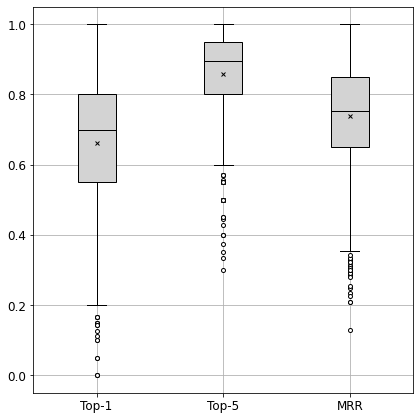

In [14]:
font = {'family' : 'normal',
        'size'   : 12}
pyplt.rc('font', **font)
pyplt.rcParams["figure.figsize"] = (6,6)

flierprops = dict(marker='o', markerfacecolor='white', markersize=4,
                  linestyle='none', markeredgecolor='black')
meanprops = dict(marker='x', markerfacecolor='white', markersize=4,
                  linestyle='none', markeredgecolor='black')
plt,param = plot_data.boxplot(column=['Top-1','Top-5','MRR'],vert=True, patch_artist=True,return_type='both', 
                              showmeans=True, flierprops=flierprops,meanprops=meanprops)
for p in param['boxes']:
    p.set_facecolor('lightgray')
    p.set_edgecolor('black')
for p in param['medians']:
    p.set_color('black')
for p in param['whiskers']:
    p.set_color('black')
for p in param['caps']:
    p.set_color('black')
for p in param['fliers']:
    p.set_color('gray')
plt.get_figure().tight_layout()
plt.get_figure().savefig('plot_images/floralens_baseline_results_boxplots.pdf')